<a href="https://colab.research.google.com/github/springboardmentor12458j/LiveMeetingSummarize/blob/Maruthi-rao-are/Extract_frame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total frames in video: 449
Extracting frames at indices: [0, 149, 299, 448]
Saved frames/frame_000.jpg
Saved frames/frame_001.jpg
Saved frames/frame_002.jpg
Saved frames/frame_003.jpg
Extracted the frames successfully.
Saved images:
Total 4 frames saved to 'frames' folder.


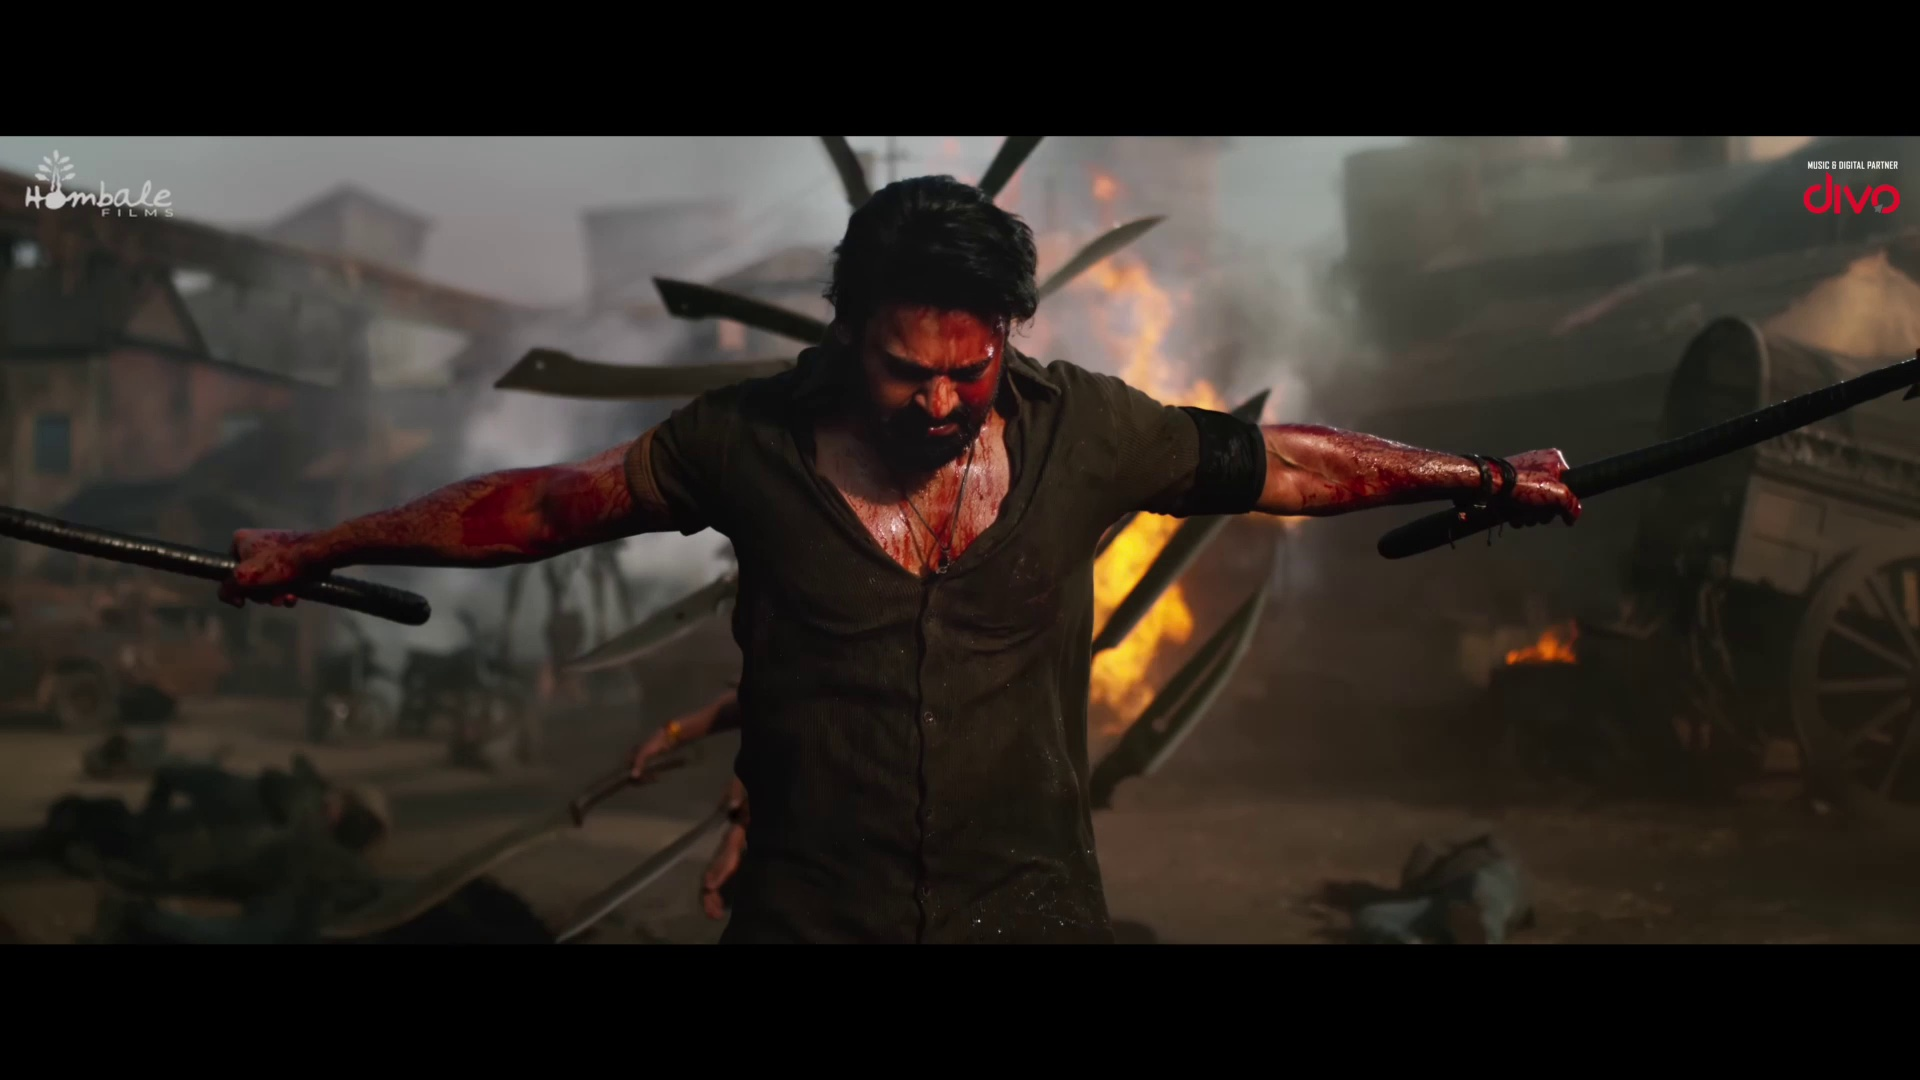

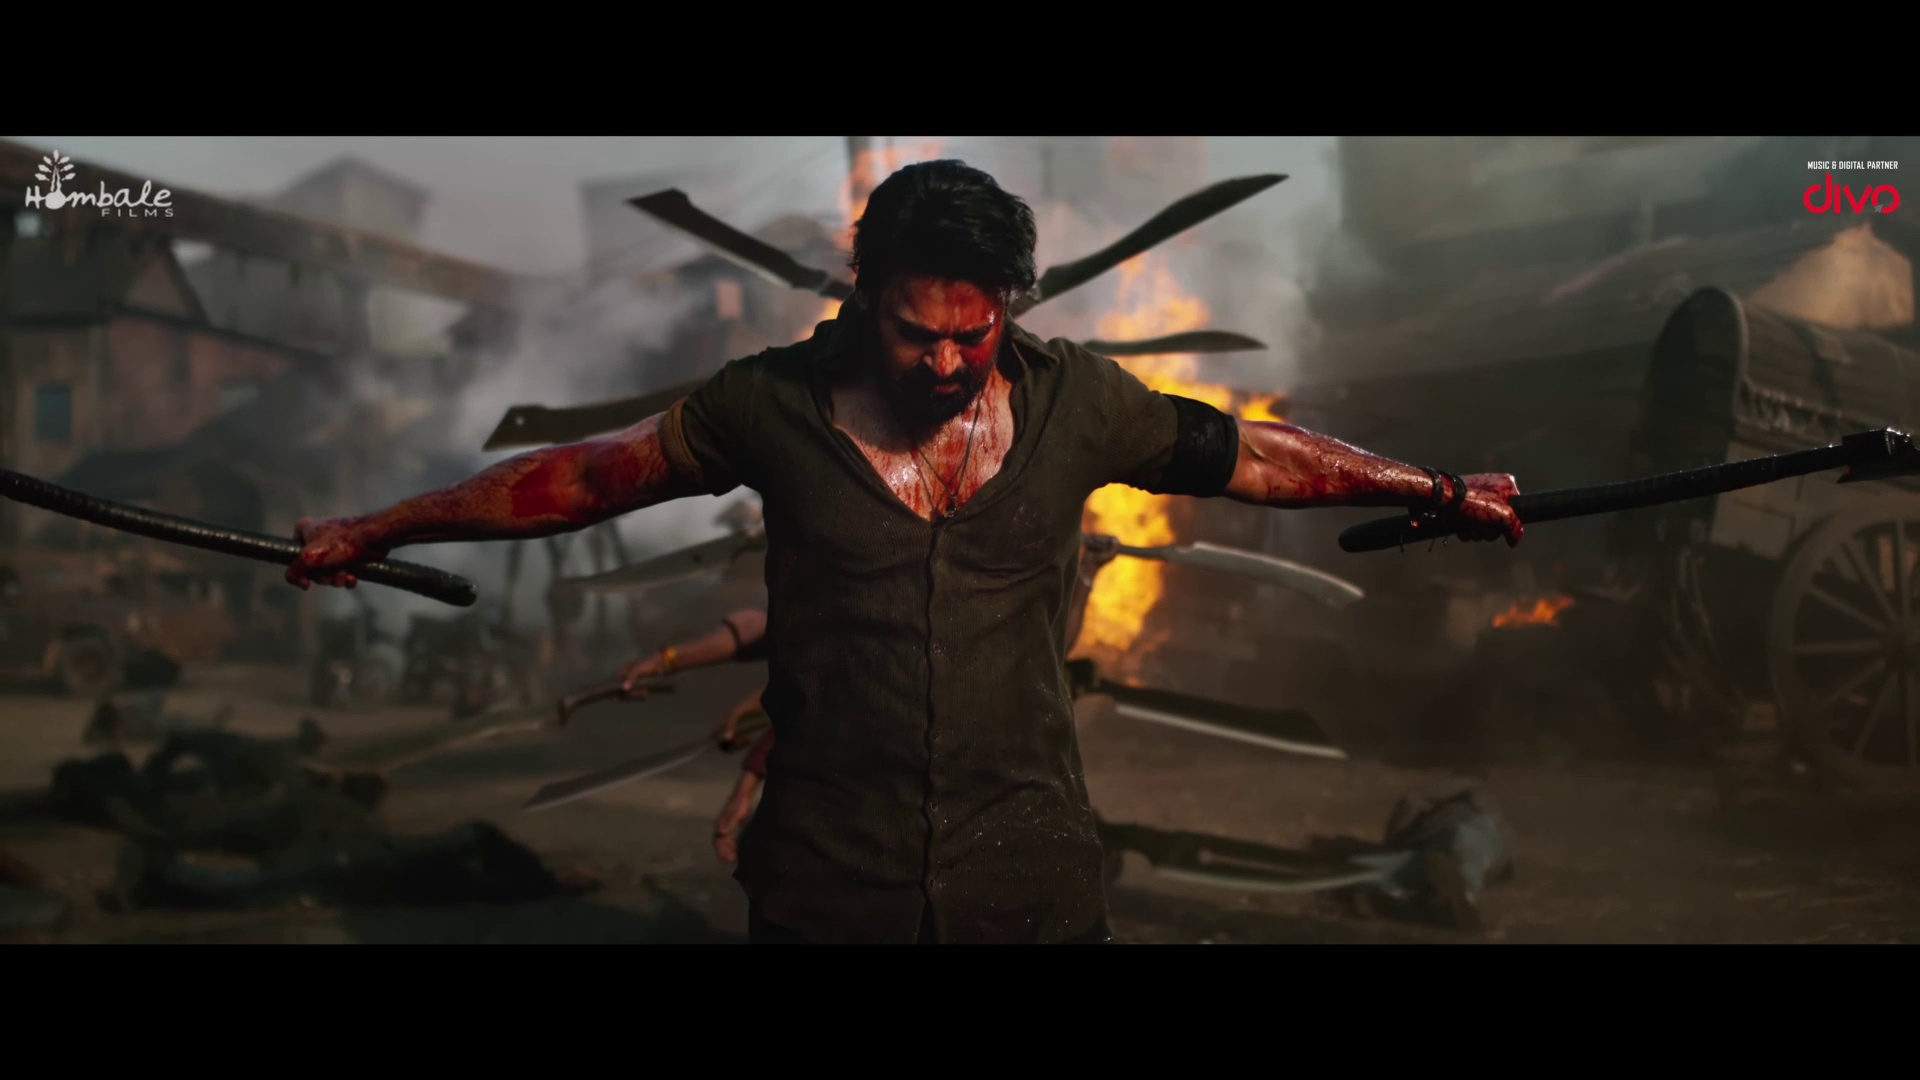

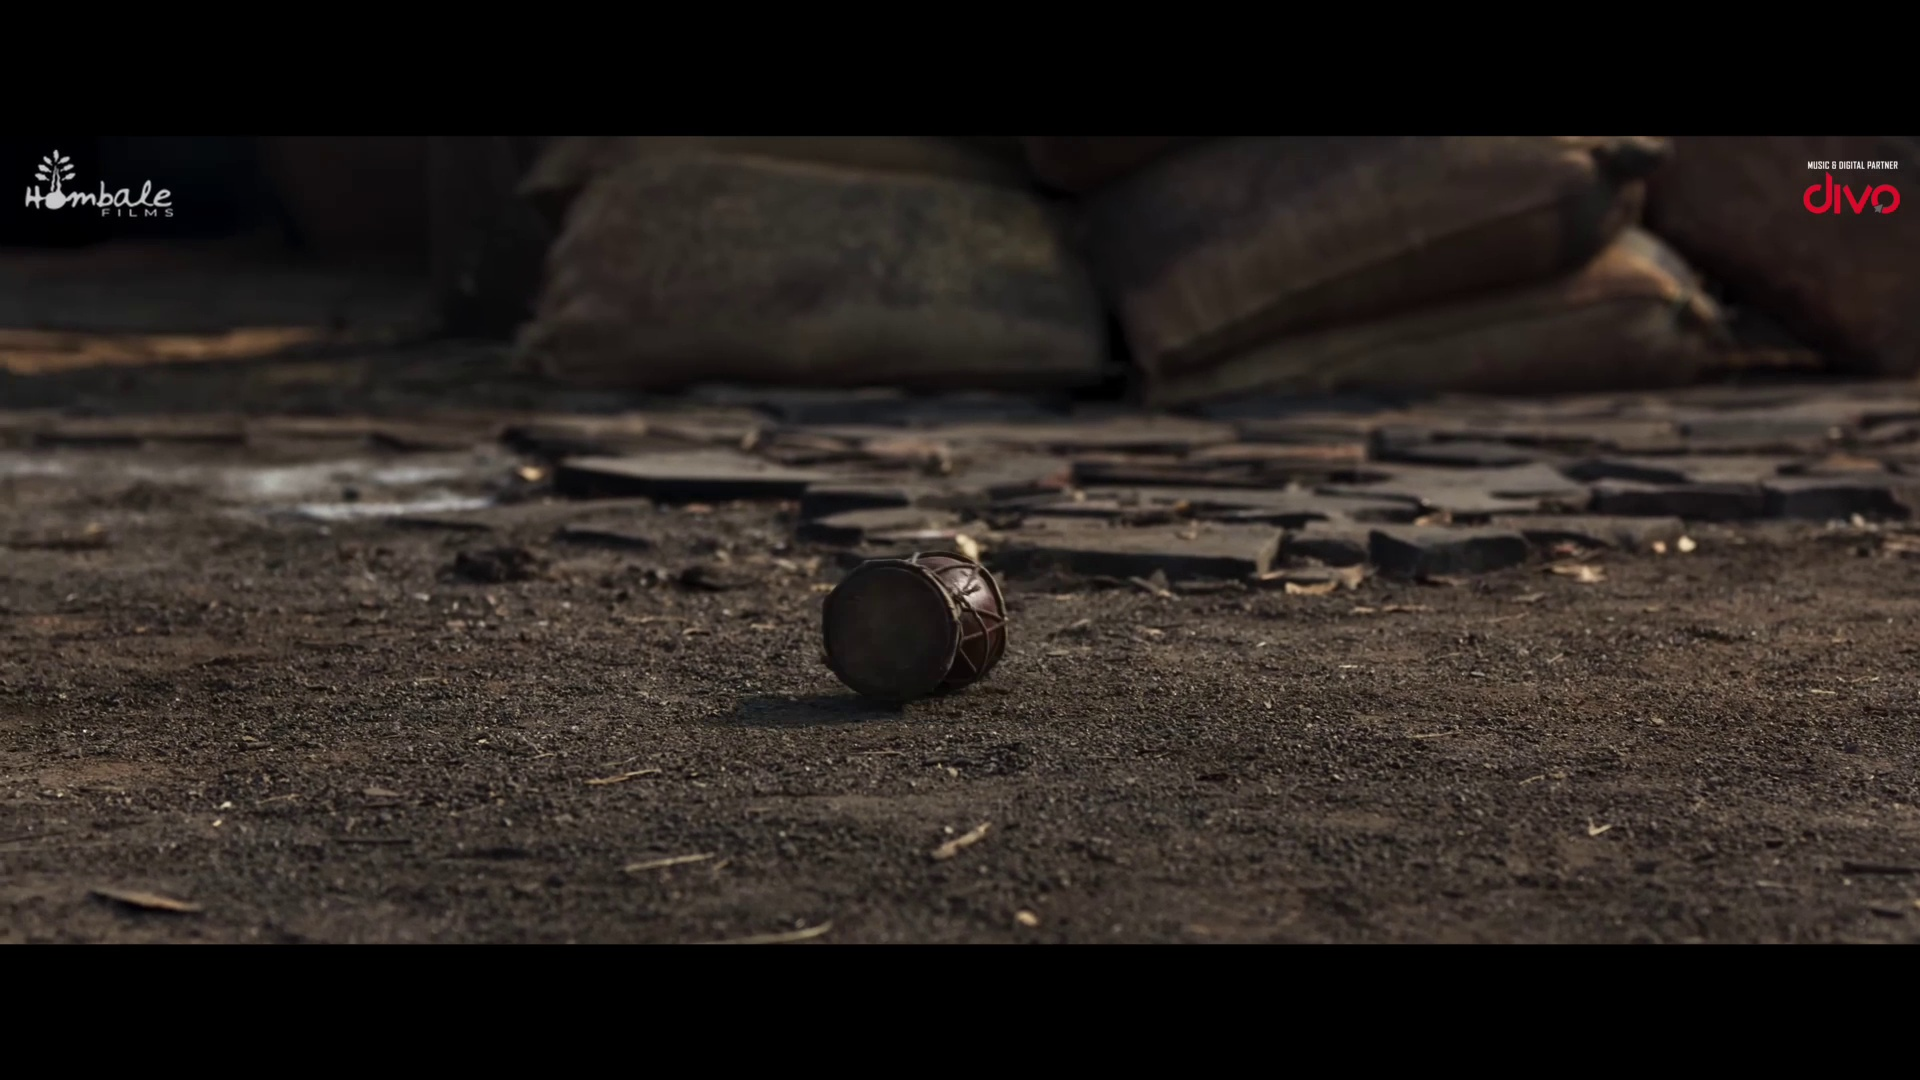

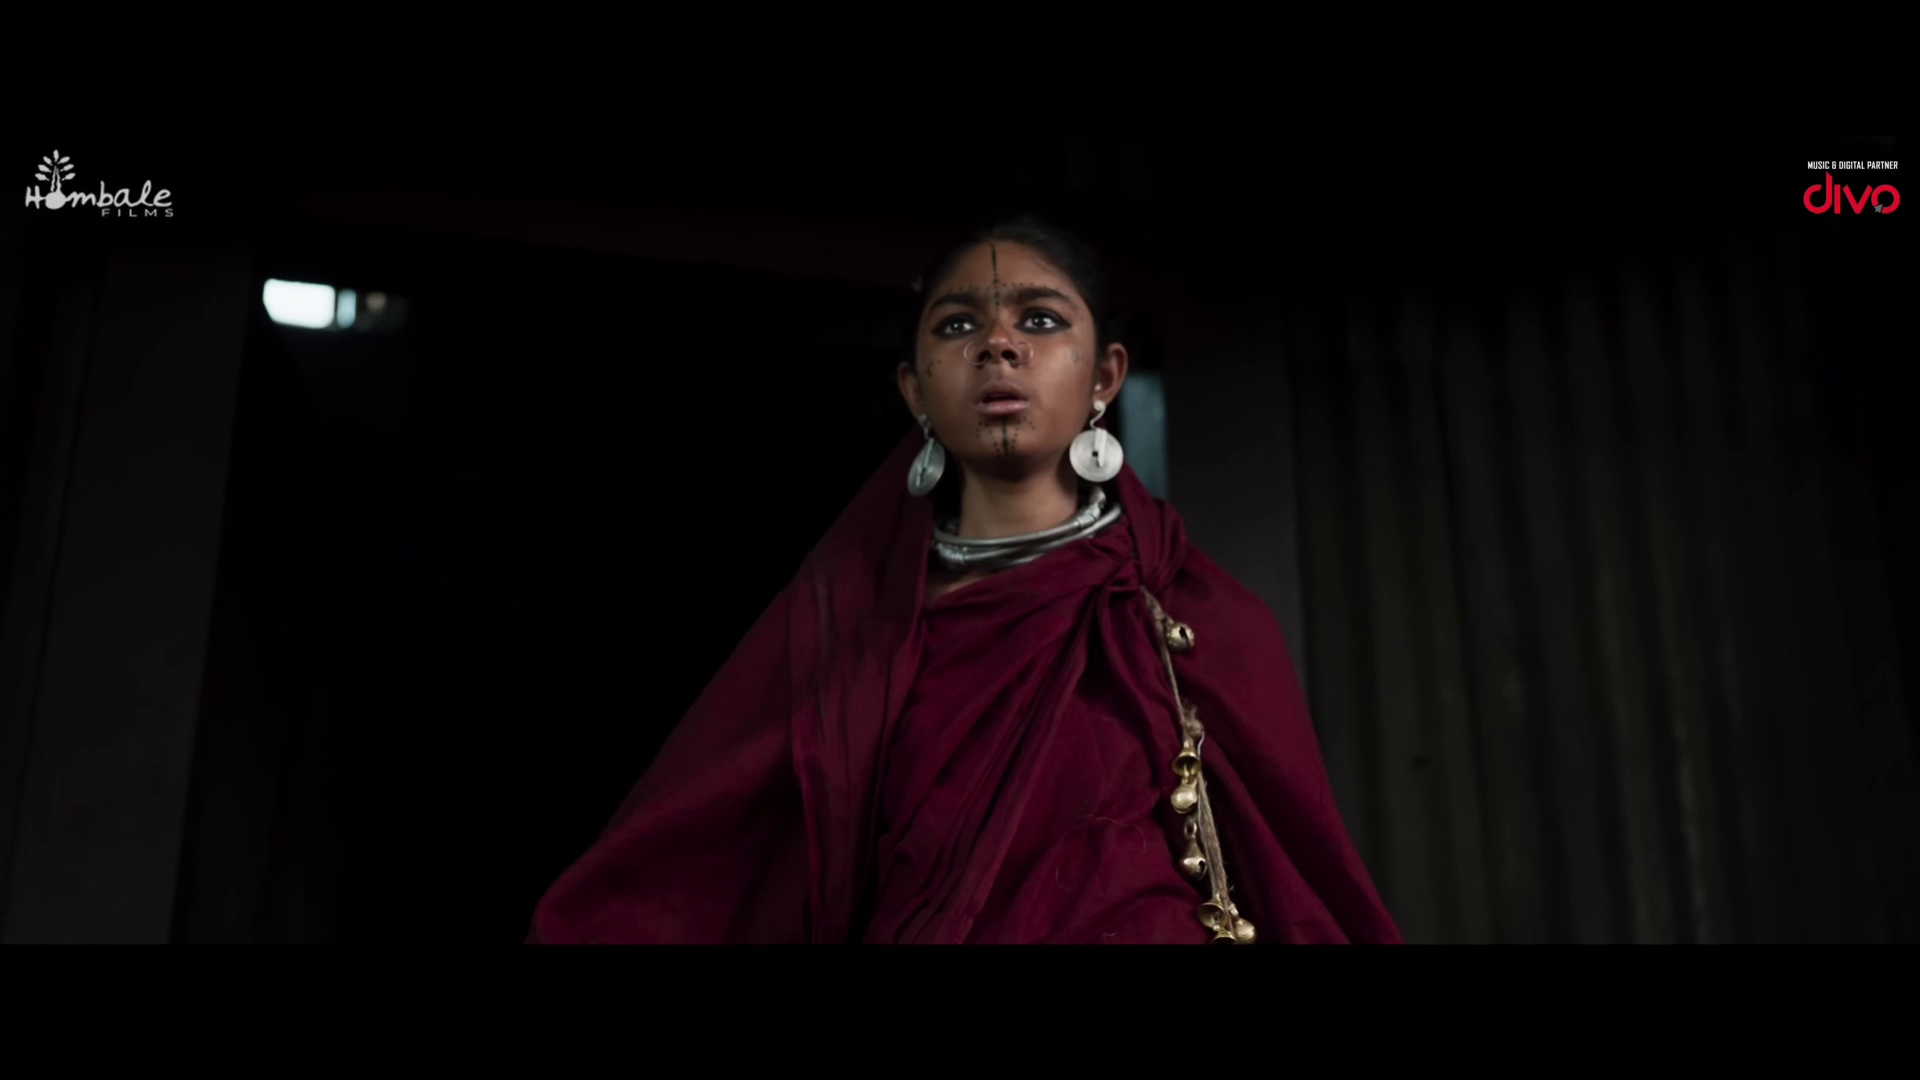

In [4]:
import cv2  # cv2: Imports OpenCV, a powerful library for image and video processing
import os
from IPython.display import Image


# Path to your video file
video_path = "/content/Deva.mp4"


# Folder to save extracted frames
output_folder = "frames"


# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)


# Load the video
cap = cv2.VideoCapture(video_path)


# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()


# Get total number of frames in the video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Total frames in video: {total_frames}")

# Number of frames to extract
num_frames_to_extract = 4

# Calculate frame indices to extract (evenly distributed)
frame_indices = [int(total_frames * i / (num_frames_to_extract - 1)) for i in range(num_frames_to_extract)]
frame_indices[-1] = min(frame_indices[-1], total_frames - 1)

print(f"Extracting frames at indices: {frame_indices}")

# Extract specific frames
frame_count = 0
for idx, frame_no in enumerate(frame_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()

    if ret:
        frame_filename = os.path.join(output_folder, f"frame_{idx:03d}.jpg")
        cv2.imwrite(frame_filename, frame)
        print(f"Saved {frame_filename}")
        frame_count += 1


# Release resources
cap.release()
cv2.destroyAllWindows()
print("Extracted the frames successfully.")


# List saved images in the frames folder
print("Saved images:")
# print(os.listdir(output_folder)) # Commenting out as it can be very long for many frames
print(f"Total {frame_count} frames saved to '{output_folder}' folder.")


# Display all extracted frames
# Warning: Displaying many images directly in the notebook output can make it very long.
# Consider displaying a subset or saving to a different format for large number of frames.
for i in range(5):
    frame_path = os.path.join(output_folder, f"frame_{i:03d}.jpg")
    if os.path.exists(frame_path):
      display(Image(filename=frame_path))